In [2]:
! pip install -U langgraph langchain-anthropic langchain-core langchain-community dotenv tavily

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from typing import Annotated, TypedDict, List
from langgraph.graph import StateGraph, END
import dotenv
from langchain_anthropic import ChatAnthropic
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, AIMessage, ChatMessage
from tavily import TavilyClient
import os
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

In [4]:
dotenv.load_dotenv()

True

In [5]:
class AgentState(TypedDict):
    task:str
    plan:str
    draft:str
    critique:str
    content: List[str]
    revision:int
    max_revision:int


In [6]:
model = ChatAnthropic(model_name="claude-opus-4-8")

In [7]:
PLAN_PROMPT = """You are an expert writer tasked with writing a high level outline of an essay. \
Write such an outline for the user provided topic. Give an outline of the essay along with any relevant notes \
or instructions for the sections."""

In [8]:
RESEARCH_PLAN_PROMPT = """You are a researcher charged with providing information that can \
be used when writing the following essay. Generate a list of search queries that will gather \
any relevant information. Only generate 3 queries max."""

In [9]:
WRITER_PROMPT = """You are an essay assistant tasked with writing excellent 5-paragraph essays.\
Generate the best essay possible for the user's request and the initial outline. \
If the user provides critique, respond with a revised version of your previous attempts. \
Utilize all the information below as needed: 

------

{content}"""

In [10]:
REFLECTION_PROMPT = """You are a teacher grading an essay submission. \
Generate critique and recommendations for the user's submission. \
Provide detailed recommendations, including requests for length, depth, style, etc."""

In [11]:
RESEARCH_CRITIQUE_PROMPT = """You are a researcher charged with providing information that can \
be used when making any requested revisions (as outlined below). \
Generate a list of search queries that will gather any relevant information. Only generate 3 queries max."""


In [12]:
from pydantic import BaseModel

class Queries(BaseModel):
    queries: List[str]

In [13]:
tavily = TavilyClient(api_key=os.getenv("TAVILY_API_KEY"))

In [14]:
def plan_node(state:AgentState):
    messages = [
        SystemMessage(PLAN_PROMPT),
        HumanMessage(state["task"])
    ]
    response = model.invoke(messages)
    return {"plan":response.content}

In [15]:
def research_plan_node(state:AgentState):
    queries = model.with_structured_output(Queries).invoke([
        SystemMessage(RESEARCH_PLAN_PROMPT),
        HumanMessage(state["task"])
    ])
    content = state.get("content") or []
    for query in queries.queries:
        response = tavily.search(query=query,max_results=2)
        for r in response["results"]:
            content.append(r["content"])
    return {"content":content}

In [16]:
def generation_node(state:AgentState):
    content = "\n".join(state['content'] or [])
    user_message = HumanMessage(content=f"{state['task']}\n\nHere is my plan:\n\n{state['plan']}")
    messages = [SystemMessage(content=WRITER_PROMPT.format(content=content)),user_message]
    response = model.invoke(messages)
    return {
        "draft":response.content,
        "revision": state.get("revision",1) + 1
        }

In [17]:
def reflection_node(state:AgentState):
    messages = [
        SystemMessage(REFLECTION_PROMPT),
        HumanMessage(state["draft"])
    ]
    response = model.invoke(messages)
    return {
        "critique":response.content
    }

In [18]:
def research_critique_node(state:AgentState):
    queries = model.with_structured_output(Queries).invoke(
        [SystemMessage(RESEARCH_CRITIQUE_PROMPT),
         HumanMessage(state.get("critique"))]
    )
    content = state.get("content") or []
    for query in queries.queries:
        response = tavily.search(query,max_results=2)
        for r in response['results']:
            content.append(r['content'])
    return {"content":content}

In [19]:
def should_continue(state:AgentState):
    if state["revision"] > state["max_revision"]:
        return END
    return 'reflect'

In [20]:
builder = StateGraph(AgentState)

builder.add_node("plan",plan_node)
builder.add_node("research",research_plan_node)
builder.add_node("generate",generation_node)
builder.add_node("reflect",reflection_node)
builder.add_node("research_critique",research_critique_node)

In [21]:
builder.add_edge("plan","research")
builder.add_edge("research","generate")
builder.add_conditional_edges("generate",should_continue,{END:END,"reflect":"reflect"})
builder.add_edge("reflect","research_critique")
builder.add_edge("research_critique","generate")

In [22]:
builder.set_entry_point("plan")

In [23]:
graph = builder.compile(checkpointer=memory)

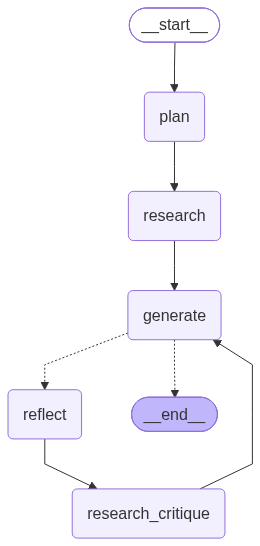

In [24]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [25]:
thread = {"configurable": {"thread_id": "2"}}
for s in graph.stream({
    'task': "what is the difference between langchain and langsmith",
    "max_revision": 2,
    "revision": 1,
}, thread):
    print(s)

{'plan': {'plan': '# Essay Outline: Understanding the Difference Between LangChain and LangSmith\n\n## Introduction\n- Brief overview of the growing ecosystem of tools for building LLM (Large Language Model) applications\n- Introduce LangChain and LangSmith as two complementary products from the same company (LangChain, Inc.)\n- Thesis: While often mentioned together and designed to work in tandem, LangChain and LangSmith serve fundamentally different purposes—one is a development framework, the other an operational/observability platform\n\n*Note: Clarify early that these are not competing tools but rather parts of a unified ecosystem to prevent reader confusion.*\n\n## Section 1: What is LangChain?\n- Definition: An open-source framework for building applications powered by LLMs\n- Core purpose: Simplifies development by providing building blocks (chains, agents, memory, retrievers)\n- Key features:\n  - Modular components and integrations with various LLM providers\n  - Support for 